## A

State the input, output and clinical question in your own words:

The input of this task is greyscale images, FINISH THIS

Import Libraries

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom
import random
from pathlib import Path
import sys
import importlib.util
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, TensorDataset
from torchvision.transforms import v2, InterpolationMode
from torchvision import models
import json

RANDOM_SEED_VALUE = 100
np.random.default_rng(RANDOM_SEED_VALUE)
torch.manual_seed(RANDOM_SEED_VALUE)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(device)



mps


In [87]:
DATA_ROOT = Path("dataset")
LABEL_FILE = Path("assignment1supportingfiles/assignment1_labels.csv")
MAPPING_FILE = Path("assignment1supportingfiles/rsna_to_nih_mapping.csv")


dicom_files = list(DATA_ROOT.rglob("*.dcm"))
print("DICOM files found:", len(dicom_files))
print("Label file found:", LABEL_FILE.exists())
print("Mapping file found:", MAPPING_FILE.exists())
assert len(dicom_files) > 0, "No DICOM files were found."
assert LABEL_FILE.exists(), "The label file was not found."
assert MAPPING_FILE.exists(), "The mapping file was not found."

DICOM files found: 25684
Label file found: True
Mapping file found: True


In [88]:
#Get the labelled CSV file as a Pandas dataframe
df = pd.read_csv("assignment1supportingfiles/assignment1_labels.csv")

saved_copy = df.copy() #Just save the dataset for later

mapping = pd.read_csv("assignment1supportingfiles/rsna_to_nih_mapping.csv")

print(f"Labels CSV file: Number of rows: {len(df)}")
#Drop the irrelevant columns
labels_df = df[["patientId", "Target", "StudyInstanceUID"]]


print(f"Number of duplicate patient Ids: {labels_df['patientId'].duplicated().sum()}")

labels_df = labels_df.drop_duplicates(subset="patientId")
print(f"Number of unique examinations and source patients: {len(labels_df)}")

print(f"Class distributions by count: {labels_df["Target"].value_counts()}")

print(f"Class distributions by percentage: {labels_df["Target"].value_counts(normalize=True) * 100}")


# Set train test split sizes
train_percentage = 0.8
test_percentage = validation_percentage = (1 - train_percentage) / 2



labels_df = pd.merge(labels_df,mapping, how="inner", on="patientId", validate="1:1" )
labels_df = labels_df[["patientId", "nih_patient_id", "Target", "nih_image_id"]]
print(labels_df.head())



Labels CSV file: Number of rows: 28989
Number of duplicate patient Ids: 3305
Number of unique examinations and source patients: 25684
Class distributions by count: Target
0    20025
1     5659
Name: count, dtype: int64
Class distributions by percentage: Target
0    77.966828
1    22.033172
Name: proportion, dtype: float64
                                           patientId  nih_patient_id  Target  \
0  1.2.276.0.7230010.3.1.4.8323329.5872.151787431...           20276       0   
1  1.2.276.0.7230010.3.1.4.8323329.15466.15178743...            3755       0   
2  1.2.276.0.7230010.3.1.4.8323329.10973.15178743...            6774       1   
3  1.2.276.0.7230010.3.1.4.8323329.22658.15178744...            4413       0   
4  1.2.276.0.7230010.3.1.4.8323329.18672.15178744...            8037       1   

       nih_image_id  
0  00020276_000.png  
1  00003755_000.png  
2  00006774_005.png  
3  00004413_002.png  
4  00008037_002.png  


## B

In [89]:
sgkf = StratifiedGroupKFold(n_splits=round(1 / test_percentage), random_state=RANDOM_SEED_VALUE, shuffle=True)
train_id, test_id = next(sgkf.split(labels_df, labels_df["Target"], groups=labels_df["nih_patient_id"]))

train_val_df = labels_df.iloc[train_id]
test_df = labels_df.iloc[test_id].copy()

#Do it again to get validation


sgkf = StratifiedGroupKFold(n_splits=round((1 - test_percentage) / validation_percentage), random_state=RANDOM_SEED_VALUE, shuffle=True)
train_id, val_id = next(sgkf.split(train_val_df, train_val_df["Target"], groups=train_val_df["nih_patient_id"]))
train_df = train_val_df.iloc[train_id].copy()
val_df = train_val_df.iloc[val_id].copy()

print(f"Count size of splits.\n train: {len(train_df)}\n validation: {len(val_df)}\n test: {len(test_df)} \n total: {len(val_df) + len(train_df) + len(test_df)}")
print(f"Percentage size of splits.\n train: {len(train_df) / len(labels_df)}\n validation: {len(val_df) / len(labels_df)}\n test: {len(test_df) / len(labels_df)}")
print("#" * 40)

print(f"Class distributions per split.\n train:{train_df["Target"].value_counts(normalize=True)}\n validation:{val_df["Target"].value_counts(normalize=True)}\n test:{test_df["Target"].value_counts(normalize=True)}")

set_train_df = set(train_df["nih_patient_id"])
set_val_df = set(val_df["nih_patient_id"])
set_test_df = set(test_df["nih_patient_id"])


Count size of splits.
 train: 20327
 validation: 2664
 test: 2693 
 total: 25684
Percentage size of splits.
 train: 0.7914265690702382
 validation: 0.10372216165706276
 test: 0.10485126927269896
########################################
Class distributions per split.
 train:Target
0    0.777242
1    0.222758
Name: proportion, dtype: float64
 validation:Target
0    0.792042
1    0.207958
Name: proportion, dtype: float64
 test:Target
0    0.785741
1    0.214259
Name: proportion, dtype: float64


In [90]:
dicom_files = list(Path("dataset").rglob("*.dcm"))
print(pydicom.dcmread(dicom_files[0]))


mapping = {file.stem: file for file in dicom_files}


for d in (train_df, val_df, test_df):
    d["image_path"] = d["patientId"].map(mapping)

assert train_df["image_path"].notna().all()
assert test_df["image_path"].notna().all()
assert val_df["image_path"].notna().all()
assert set_train_df.isdisjoint(set_val_df)
assert set_train_df.isdisjoint(set_test_df)
assert set_val_df.isdisjoint(set_test_df)


#Now ALL i need is just the nih_pateint_id, Target and image location
train_df = train_df[["nih_patient_id", "Target", "image_path"]]
test_df = test_df[["nih_patient_id", "Target", "image_path"]]
val_df = val_df[["nih_patient_id", "Target", "image_path"]]

print(train_df.head())

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 202
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Secondary Capture Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.276.0.7230010.3.1.4.8323329.13028.1517874368.999134
(0002,0010) Transfer Syntax UID                 UI: JPEG Baseline (Process 1)
(0002,0012) Implementation Class UID            UI: 1.2.276.0.7230010.3.0.3.6.0
(0002,0013) Implementation Version Name         SH: 'OFFIS_DCMTK_360'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0016) SOP Class UID                       UI: Secondary Capture Image Storage
(0008,0018) SOP Instance UID                    UI: 1.2.276.0.7230010.3.1.4.8323329.13028.1517874368.999134
(0008,0020) Study Date                          DA: '19010101'
(0008,0030) Study Time                  

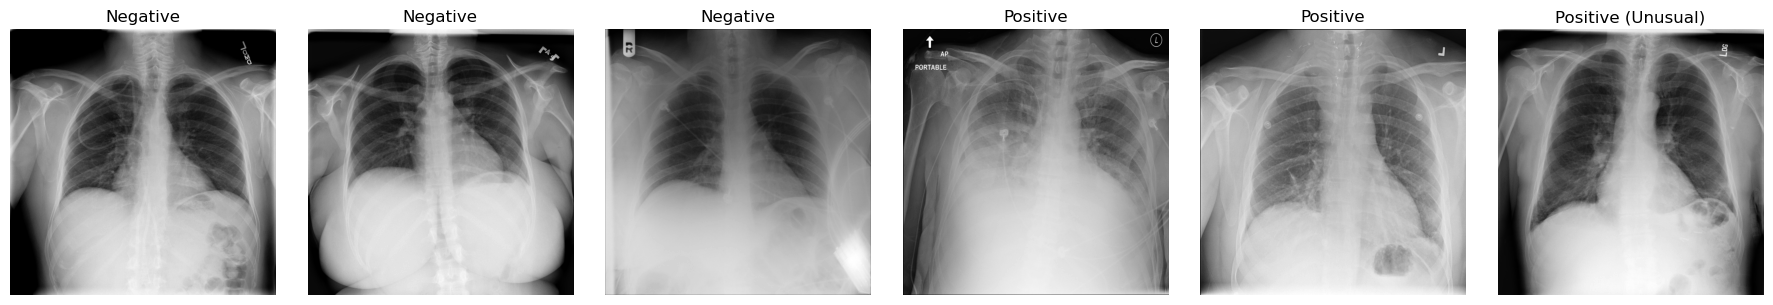

In [92]:
pos_boxes = saved_copy[saved_copy["Target"] == 1].dropna(subset=["width", "height"]).copy()
pos_boxes["box_area"] = pos_boxes["width"] * pos_boxes["height"]
tiny_id = pos_boxes.sort_values("box_area").iloc[0]["patientId"]

neg_ids = labels_df[labels_df["Target"] == 0]["patientId"].sample(3, random_state=0).tolist()
pos_ids = labels_df[(labels_df["Target"] == 1) & (labels_df["patientId"] != tiny_id)]["patientId"].sample(2, random_state=0).tolist()

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
titles = ["Negative"] * 3 + ["Positive"] * 2 + ["Positive (Unusual)"]
ids = neg_ids + pos_ids + [tiny_id]

for ax, pid, title in zip(axes, ids, titles):
    img = pydicom.dcmread(mapping[pid]).pixel_array
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

## C

In [93]:
# My plan is to 1) Make a function that, given a path, retreives the image

def load_image(path):
    image = pydicom.dcmread(path, stop_before_pixels=False)
    image_pixels = image.pixel_array

    #Convert to torch tensor

    image_pixels = torch.from_numpy(image_pixels)
    image_pixels = torch.unsqueeze(image_pixels, 0)

    #Normalise values 
    amax, amin = image_pixels.max(), image_pixels.min()
    image_pixels = (image_pixels - amin) / (amax - amin)

    #Resize to 224 x 224

    resize_transform = v2.Resize((224, 224), antialias=True)
    image_pixels = resize_transform(image_pixels)

    return image_pixels


imagenet_mean=sum([0.485, 0.456, 0.406]) / 3
imagenet_std=sum([0.229, 0.224, 0.225]) / 3

#RStandardisation transform
normalize = v2.Normalize(mean=[imagenet_mean], std=[imagenet_std])

train_transform = v2.Compose([
    v2.RandomAffine(degrees=10, translate=(0.03, 0.03), interpolation=InterpolationMode.BILINEAR),
    v2.ColorJitter(brightness=0.1, contrast=0.1),
    normalize
])
val_test_transform = v2.Compose([normalize])



Make the datasets

In [94]:
class Pneumonia_Dataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        #For a given index, return the image and label in that order
        row = self.df.iloc[index]
        path = row["image_path"]
        image_pixels = load_image(path=path)
        label = row["Target"]
        if self.transform is not None:
            image_pixels = self.transform(image_pixels)

        #squeeze the extra dimension again
        image_pixels = image_pixels.squeeze(0)
        image_pixels = np.stack([image_pixels] * 3, axis=0)

        
        return torch.tensor(image_pixels, dtype=torch.float32), torch.tensor(label, dtype=torch.float32)


#THE model datasets and dataloaders
train_ds = Pneumonia_Dataset(train_df, transform=train_transform)
val_ds = Pneumonia_Dataset(val_df, transform=val_test_transform)
test_ds = Pneumonia_Dataset(test_df, transform=val_test_transform)


train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0)



        

## D

In [95]:
def trivial_baseline(df):
    mode_class = 0
    pred = len(df) * [mode_class]
    return classification_report(df["Target"], pred, zero_division=0)

print(f"Validation: {trivial_baseline(val_df)}")
print(f"Test: {trivial_baseline(test_df)}")


Validation:               precision    recall  f1-score   support

           0       0.79      1.00      0.88      2110
           1       0.00      0.00      0.00       554

    accuracy                           0.79      2664
   macro avg       0.40      0.50      0.44      2664
weighted avg       0.63      0.79      0.70      2664

Test:               precision    recall  f1-score   support

           0       0.79      1.00      0.88      2116
           1       0.00      0.00      0.00       577

    accuracy                           0.79      2693
   macro avg       0.39      0.50      0.44      2693
weighted avg       0.62      0.79      0.69      2693



Linear baseline

In [96]:
class Baseline_Dataset(Dataset):
    def __init__(self, df, ds_mean=None, ds_std=None):
        self.df = df.reset_index(drop=True)
        self.mean = ds_mean
        self.std = ds_std

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        path = row["image_path"]
        image_pixels = load_image(path=path)
        label = row["Target"]

        histogram, _ = np.histogram(image_pixels, bins=5, density=True)

        features = np.concatenate([[image_pixels.mean(), image_pixels.std()], histogram, np.percentile(image_pixels, [20, 40, 60, 80])], dtype=np.float32)

        if self.mean is not None and self.std is not None:
            features = (features - self.mean) / self.std



        
        return torch.tensor(features), torch.tensor(label, dtype=torch.float32)


#now get the mean and standard deviation for each
x = Baseline_Dataset(train_df)
nums = torch.stack([x[i][0] for i in range(len(x))])
mean = nums.mean(dim=0).numpy()
std = nums.std(dim=0).numpy() + 1e-8

print(f"mean: {mean}, std: {std}")

baseline_train_dataset = Baseline_Dataset(train_df, ds_mean=mean, ds_std=std)
baseline_val_dataset = Baseline_Dataset(val_df, ds_mean=mean, ds_std=std)
baseline_test_dataset = Baseline_Dataset(test_df, ds_mean=mean, ds_std=std)

def materialize(ds):
    features, labels = [], []
    for i in range(len(ds)):
        feature, label = ds[i]
        features.append(feature)
        labels.append(label)
    return torch.stack(features), torch.stack(labels)

X_train, y_train = materialize(baseline_train_dataset)
X_val, y_val     = materialize(baseline_val_dataset)
X_test, y_test   = materialize(baseline_test_dataset)

baseline_train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
baseline_val_loader   = DataLoader(TensorDataset(X_val, y_val),     batch_size=32, shuffle=False)
baseline_test_loader  = DataLoader(TensorDataset(X_test, y_test),   batch_size=32, shuffle=False)



mean: [0.5056559  0.23393825 0.7431167  0.83682734 1.303248   1.4506134
 1.059147   0.29272917 0.4582477  0.5936848  0.72843987], std: [0.09179639 0.04045991 0.45752698 0.39018896 0.44324148 0.534393
 0.64431256 0.13045704 0.12051141 0.10646852 0.09193703]


In [102]:
class LogisticBaseline(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.linear = nn.Linear(num_features, 1)

    def forward(self, x):
        return self.linear(x).squeeze(1) #We would get [batchsize, 1] by the end so just remove this 1


model = LogisticBaseline(num_features=11)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_func = nn.BCEWithLogitsLoss()

best_val_accuracy = 0
best_state = None

for epoch in range(50):
    model.train()
    for x, y in baseline_train_loader:
        optimizer.zero_grad()
        loss = loss_func(model(x), y)
        loss.backward()
        optimizer.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in baseline_val_loader:
            preds = (torch.sigmoid(model(x)) > 0.5).float()
            correct += (preds == y).sum().item()
            total += y.size(0)
    val_accuracy = correct / total

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_state = model.state_dict()

    print(f"Epoch {epoch+1}: val_accuracy={val_accuracy:.4f}")

model.load_state_dict(best_state)
logistic_model = model

Epoch 1: val_accuracy=0.7902
Epoch 2: val_accuracy=0.7894
Epoch 3: val_accuracy=0.7909
Epoch 4: val_accuracy=0.7849
Epoch 5: val_accuracy=0.7842
Epoch 6: val_accuracy=0.7909
Epoch 7: val_accuracy=0.7909
Epoch 8: val_accuracy=0.7812
Epoch 9: val_accuracy=0.7887
Epoch 10: val_accuracy=0.7875
Epoch 11: val_accuracy=0.7898
Epoch 12: val_accuracy=0.7898
Epoch 13: val_accuracy=0.7857
Epoch 14: val_accuracy=0.7838
Epoch 15: val_accuracy=0.7909
Epoch 16: val_accuracy=0.7890
Epoch 17: val_accuracy=0.7887
Epoch 18: val_accuracy=0.7894
Epoch 19: val_accuracy=0.7883
Epoch 20: val_accuracy=0.7857
Epoch 21: val_accuracy=0.7857
Epoch 22: val_accuracy=0.7879
Epoch 23: val_accuracy=0.7853
Epoch 24: val_accuracy=0.7868
Epoch 25: val_accuracy=0.7905
Epoch 26: val_accuracy=0.7898
Epoch 27: val_accuracy=0.7883
Epoch 28: val_accuracy=0.7845
Epoch 29: val_accuracy=0.7898
Epoch 30: val_accuracy=0.7864
Epoch 31: val_accuracy=0.7883
Epoch 32: val_accuracy=0.7872
Epoch 33: val_accuracy=0.7898
Epoch 34: val_accur

In [107]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in baseline_test_loader:
        preds = (torch.sigmoid(model(x)) > 0.5).float()
        all_preds.append(preds)
        all_labels.append(y)

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

print(classification_report(all_labels, all_preds, zero_division=0))

              precision    recall  f1-score   support

         0.0       0.80      0.98      0.88      2116
         1.0       0.55      0.07      0.13       577

    accuracy                           0.79      2693
   macro avg       0.67      0.53      0.50      2693
weighted avg       0.74      0.79      0.72      2693



## E

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, 1) 
    return model

#Adding after the fact knowledge that pos_weight is better
num_pos = (train_df["Target"] == 1).sum()
num_neg = (train_df["Target"] == 0).sum()
pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(device)


def train_stage_1(model, optimizer, loss_func, epochs, train_losses, val_losses, best_val_accuracy=0, best_state=None):
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        for X, Y in train_loader:
            X, Y = X.to(device), Y.to(device)
            optimizer.zero_grad()
            loss = loss_func(model(X).squeeze(1), Y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * X.size(0)
        train_losses.append(running_loss / len(train_loader.dataset))

        model.eval()
        correct, total = 0, 0
        val_running_loss = 0
        with torch.no_grad():
            for X, Y in val_loader:
                X, Y = X.to(device), Y.to(device)
                out = model(X).squeeze(1)
                preds = (torch.sigmoid(out) > 0.5).float()
                val_running_loss += loss_func(out, Y).item() * X.size(0)
                correct += (preds == Y).sum().item()
                total += Y.size(0)
        val_losses.append(val_running_loss / len(val_loader.dataset))
        val_accuracy = correct / total

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"Epoch {epoch+1}/{epochs}: val_acc={val_accuracy:.4f}")
    return best_val_accuracy, best_state


def train_CNN(seed, stage_1_epochs=5, stage_2_epochs=5):
    set_seed(seed)
    model = build_model().to(device)
    loss_func = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    train_losses, val_losses = [], []

    #Stage 1
    for param in model.parameters():
        param.requires_grad = False
    for param in model.fc.parameters():
        param.requires_grad = True

    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    best_val_accuracy, best_state = train_stage_1(model, optimizer, loss_func, stage_1_epochs, train_losses=train_losses, val_losses=val_losses)
    model.load_state_dict(best_state)

    #Stage 2
    for name, param in model.named_parameters():
        if name.startswith("layer4") or name.startswith("fc"):
            param.requires_grad = True

    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
    best_val_accuracy, best_state = train_stage_1(model, optimizer, loss_func, stage_2_epochs, train_losses, val_losses, best_val_accuracy, best_state)
    model.load_state_dict(best_state)

    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X, Y in test_loader:
            X, Y = X.to(device), Y.to(device)
            pred = (torch.sigmoid(model(X).squeeze(1)) > 0.5).float()
            preds.append(pred.cpu())
            labels.append(Y.cpu())
    preds = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()

    metric = f1_score(labels, preds, zero_division=0)
    return metric, model, train_losses, val_losses

#Plot train and validation loss for just 0






seeds = [0, 1, 2]
results = []

for seed in seeds:
    print(f"Seed {seed}")
    metric, model, train_losses, val_losses = train_CNN(seed)
    print(f"Seed {seed} finished: F1: {metric}")
    results.append(metric)
    torch.save(model.state_dict(), f"model_seed{seed}.pt")
    if seed == 0: #Just collect train and validation losses for seed 0
        seed0_train_losses = train_losses
        seed0_val_losses = val_losses
    

results = np.array(results)
print(f"Mean F1: {results.mean()}, Std F1: {results.std()}")

plt.plot(seed0_train_losses, label="train loss")
plt.plot(seed0_val_losses, label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

    


    







Seed 0
Epoch 1/5: val_acc=0.8123
Epoch 2/5: val_acc=0.8101
Epoch 3/5: val_acc=0.8168
Epoch 4/5: val_acc=0.8116
Epoch 5/5: val_acc=0.8153
Epoch 1/5: val_acc=0.8435
Epoch 2/5: val_acc=0.8363
Epoch 3/5: val_acc=0.8393
Epoch 4/5: val_acc=0.8333
Epoch 5/5: val_acc=0.8266
Seed 0 finished: F1: 0.5452586206896551
Seed 1
Epoch 1/5: val_acc=0.8082
Epoch 2/5: val_acc=0.8176
Epoch 3/5: val_acc=0.8176
Epoch 4/5: val_acc=0.8206
Epoch 5/5: val_acc=0.8153
Epoch 1/5: val_acc=0.8270
Epoch 2/5: val_acc=0.8386
Epoch 3/5: val_acc=0.8446
Epoch 4/5: val_acc=0.8326
Epoch 5/5: val_acc=0.8296
Seed 1 finished: F1: 0.5370165745856355
Seed 2
Epoch 1/5: val_acc=0.8123
Epoch 2/5: val_acc=0.8119
Epoch 3/5: val_acc=0.7943
Epoch 4/5: val_acc=0.8168
Epoch 5/5: val_acc=0.8146
Epoch 1/5: val_acc=0.8356
Epoch 2/5: val_acc=0.8333
Epoch 3/5: val_acc=0.8442
Epoch 4/5: val_acc=0.8390
Epoch 5/5: val_acc=0.8029
Seed 2 finished: F1: 0.5576131687242798
Mean F1: 0.5466294546665235, Std F1: 0.008464211397490498


Seed 0
Epoch 1/5: val_acc=0.8123
Epoch 2/5: val_acc=0.8101
Epoch 3/5: val_acc=0.8168
Epoch 4/5: val_acc=0.8116
Epoch 5/5: val_acc=0.8153
Epoch 1/5: val_acc=0.8435
Epoch 2/5: val_acc=0.8363
Epoch 3/5: val_acc=0.8393
Epoch 4/5: val_acc=0.8333
Epoch 5/5: val_acc=0.8266
Seed 0 finished: F1: 0.5452586206896551
Seed 1
Epoch 1/5: val_acc=0.8082
Epoch 2/5: val_acc=0.8176
Epoch 3/5: val_acc=0.8176
Epoch 4/5: val_acc=0.8206
Epoch 5/5: val_acc=0.8153
Epoch 1/5: val_acc=0.8270
Epoch 2/5: val_acc=0.8386
Epoch 3/5: val_acc=0.8446
Epoch 4/5: val_acc=0.8326
Epoch 5/5: val_acc=0.8296
Seed 1 finished: F1: 0.5370165745856355
Seed 2
Epoch 1/5: val_acc=0.8123
Epoch 2/5: val_acc=0.8119
Epoch 3/5: val_acc=0.7943
Epoch 4/5: val_acc=0.8168
Epoch 5/5: val_acc=0.8146
Epoch 1/5: val_acc=0.8356
Epoch 2/5: val_acc=0.8333
Epoch 3/5: val_acc=0.8442
Epoch 4/5: val_acc=0.8390
Epoch 5/5: val_acc=0.8029
Seed 2 finished: F1: 0.5576131687242798
Mean F1: 0.5466294546665235, Std F1: 0.008464211397490498

## Task from c to address class imbalance, Add a weight to loss

In [64]:
num_pos = (train_df["Target"] == 1).sum()
num_neg = (train_df["Target"] == 0).sum()
pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(device)
print(f"pos_weight:{pos_weight.item()}")

def run_c(seed=0, stage_1_epochs=5, stage_2_epochs=5):
    results = {}
    for use_pos_weight in [False, True]:
        set_seed(seed)
        model = build_model().to(device)
        weight = pos_weight if use_pos_weight else None
        loss_func = nn.BCEWithLogitsLoss(pos_weight=weight)

        for param in model.parameters():
            param.requires_grad = False
        for param in model.fc.parameters():
            param.requires_grad = True
        optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
        best_val_accuracy, best_state = train_stage_1(model, optimizer, loss_func, stage_1_epochs)
        model.load_state_dict(best_state)

        for name, param in model.named_parameters():
            if name.startswith("layer4") or name.startswith("fc"):
                param.requires_grad = True
        optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
        best_val_accuracy, best_state = train_stage_1(model, optimizer, loss_func, stage_2_epochs, best_val_accuracy, best_state)
        model.load_state_dict(best_state)

        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for X, Y in val_loader:
                X, Y = X.to(device), Y.to(device)
                pred = (torch.sigmoid(model(X).squeeze(1)) > 0.5).float()
                preds.append(pred.cpu()); labels.append(Y.cpu())
        preds = torch.cat(preds).numpy(); labels = torch.cat(labels).numpy()

        key = "with_pos_weight" if use_pos_weight else "without_pos_weight"
        torch.save(model.state_dict(), f"model_{key}.pt")
        results[key] = classification_report(labels, preds, output_dict=True, zero_division=0)
        print(f"##{key}##")
        print(classification_report(labels, preds, zero_division=0))

    return results

ablation_results = run_c(seed=0)

pos_weight:3.489178419113159
Epoch 1/5: val_acc=0.8123
Epoch 2/5: val_acc=0.8101
Epoch 3/5: val_acc=0.8168
Epoch 4/5: val_acc=0.8116
Epoch 5/5: val_acc=0.8153
Epoch 1/5: val_acc=0.8435
Epoch 2/5: val_acc=0.8363
Epoch 3/5: val_acc=0.8393
Epoch 4/5: val_acc=0.8333
Epoch 5/5: val_acc=0.8266
##without_pos_weight##
              precision    recall  f1-score   support

         0.0       0.87      0.95      0.91      2110
         1.0       0.69      0.44      0.54       554

    accuracy                           0.84      2664
   macro avg       0.78      0.70      0.72      2664
weighted avg       0.83      0.84      0.83      2664

Epoch 1/5: val_acc=0.6982
Epoch 2/5: val_acc=0.6862
Epoch 3/5: val_acc=0.7331
Epoch 4/5: val_acc=0.7650
Epoch 5/5: val_acc=0.7658
Epoch 1/5: val_acc=0.7609
Epoch 2/5: val_acc=0.7553
Epoch 3/5: val_acc=0.7196
Epoch 4/5: val_acc=0.7211
Epoch 5/5: val_acc=0.7939
##with_pos_weight##
              precision    recall  f1-score   support

         0.0       0.91   

Grad cam

In [101]:
def gradcam(model, x, y, target_layer):
    activations, gradients = {}, {}

    def forward_hook(module, input, output):
        activations["value"] = output.detach()

    def backward_hook(module, input, output):
            gradients["value"] = output[0].detach()

    forward = target_layer.register_forward_hook(forward_hook)
    backward = target_layer.register_full_backward_hook(backward_hook)

    model.zero_grad()
    input_tensor = x.unsqueeze(0).to(device)
    logit = model(input_tensor).squeeze()
    prob = torch.sigmoid(logit).item()
    pred = int(prob > 0.5)


    logit.backward()

    forward.remove()
    backward.remove()

    #layer 4 output shape is batchsize x 512 x 7 x7. Batchsize here is 1. 
    grads = gradients["value"][0] #512 x 7 x 7
    pooled_weights = grads.mean(dim=(1, 2)) #Now just 512 as we take average of whole channel

    acts = activations["value"][0]  #512 x 7 x 7
    for i in range(acts.shape[0]):
        acts[i] *= pooled_weights[i] #Take the activations multiplied by gradient (how powerful this square was)

    #Now average
    heatmap = acts.mean(dim=0) #So now 7x7 as we averaged across all channels
    #Relu to remove negatives then range from 0 to 1 to make a valid heatmap
    heatmap = torch.relu(heatmap)
    heatmap = heatmap / heatmap.max()

    heatmap = heatmap.unsqueeze(0).unsqueeze(0) #So interpolate does not make an error
    heatmap = nn.functional.interpolate(heatmap, size=(224, 224), mode="bilinear")
    heatmap = heatmap.squeeze()
    return heatmap.cpu().numpy(), prob, pred




# Collecting all graph figures

# Check image size, photometric interpretation and projection/view information when available. 

In [ ]:
sample_paths = train_df["image_path"].sample(500, random_state=0)

sizes, photometric, views = [], [], []
for path in sample_paths:
    data = pydicom.dcmread(path, stop_before_pixels=True)
    sizes.append((data.Rows, data.Columns))
    photometric.append(data.PhotometricInterpretation)
    views.append(data.get("ViewPosition", "UNK"))

print("Unique sizes:", set(sizes))
print(pd.Series(photometric).value_counts())
print(pd.Series(views).value_counts())

Unique sizes: {(1024, 1024)}
MONOCHROME2    500
Name: count, dtype: int64
PA    275
AP    225
Name: count, dtype: int64


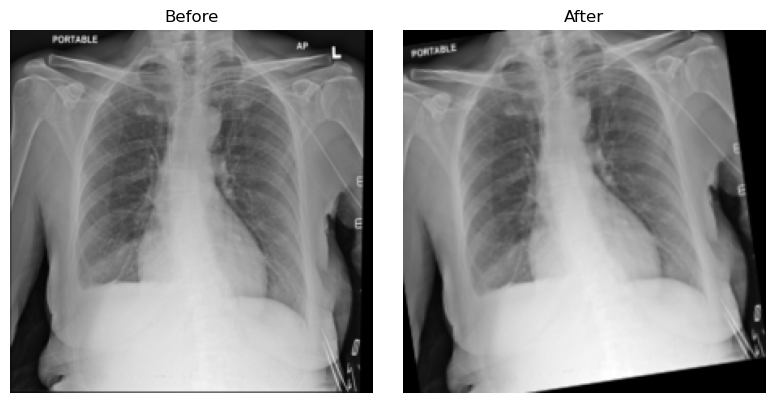

In [80]:
display_augment = v2.Compose([
    v2.RandomAffine(degrees=10, translate=(0.03, 0.03), interpolation=InterpolationMode.BILINEAR),
    v2.ColorJitter(brightness=0.1, contrast=0.1),
])

row = train_df.sample(1, random_state=2).iloc[0]
before_img = load_image(row["image_path"])
after_img = display_augment(before_img)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(before_img.squeeze().numpy(), cmap="gray"); axes[0].set_title("Before"); axes[0].axis("off")
axes[1].imshow(after_img.squeeze().numpy(), cmap="gray"); axes[1].set_title("After"); axes[1].axis("off")
plt.tight_layout()
plt.show()

In [98]:
model = build_model().to(device)
model.load_state_dict(torch.load("model_seed0.pt", map_location=device))
model.eval()

def get_probs_labels(loader):
    probs, labels = [], []
    with torch.no_grad():
        for X, Y in loader:
            X, Y = X.to(device), Y.to(device)
            p = torch.sigmoid(model(X).squeeze(1))
            probs.append(p.cpu())
            labels.append(Y.cpu())
    return torch.cat(probs).numpy(), torch.cat(labels).numpy()

test_probs, test_labels = get_probs_labels(test_loader)
val_probs, val_labels = get_probs_labels(val_loader)

def compute_metrics(probs, labels, threshold=0.5):
    preds = (probs > threshold).astype(float)
    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()
    return {
        "confusion_matrix": cm,
        "accuracy": (tp+tn)/(tp+tn+fp+fn),
        "sensitivity": tp/(tp+fn) if (tp+fn) > 0 else 0,
        "specificity": tn/(tn+fp) if (tn+fp) > 0 else 0,
        "precision": tp/(tp+fp) if (tp+fp) > 0 else 0,
        "f1": f1_score(labels, preds, zero_division=0)
    }

cnn_metrics = compute_metrics(test_probs, test_labels)
print(cnn_metrics["confusion_matrix"])
for k in ["accuracy", "sensitivity", "specificity", "precision", "f1"]:
    print(f"{k}: {cnn_metrics[k]}")

[[2018   98]
 [ 324  253]]
accuracy: 0.8432974378017082
sensitivity: 0.43847487001733104
specificity: 0.9536862003780718
precision: 0.7207977207977208
f1: 0.5452586206896551
